# Olist E-Commerce: Funnel & Cohort Retention Analysis

This notebook runs the SQL analyses in `sql/` against the raw Olist CSVs using DuckDB,
then builds the charts used in the README. All analysis logic (funnel math, cohort
retention, behavioral segmentation) lives in the `.sql` files — this notebook only
executes those queries and visualizes the results.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# SQL files reference data/ with paths relative to the project root, so run
# everything from there regardless of where Jupyter was launched.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect()

def run_sql(path):
    with open(path) as f:
        return con.execute(f.read()).df()

## 1. Order Funnel: Placed → Approved → Shipped → Delivered

In [2]:
funnel_df = run_sql('sql/01_order_funnel.sql')
funnel_df

,stage_order,stage,orders,pct_of_total,dropoff_count,dropoff_pct_of_prev_stage
0,1,Order Placed,99441,100.00,<NA>,NaN
1,2,Approved,99281,99.84,160,0.16
2,3,Shipped,97658,98.21,1623,1.63
3,4,Delivered,96476,97.02,1182,1.21


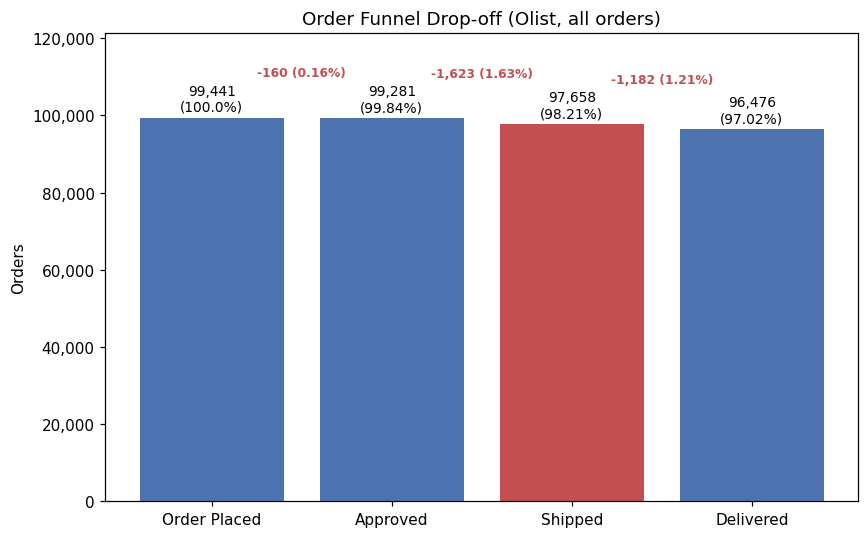

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#4C72B0', '#C44E52', '#4C72B0']  # highlight biggest leak stage
bars = ax.bar(funnel_df['stage'], funnel_df['orders'], color=colors)

top = funnel_df['orders'].max()
ax.set_ylim(0, top * 1.22)

for i, row in funnel_df.iterrows():
    ax.text(i, row['orders'] + top * 0.01, f"{row['orders']:,}\n({row['pct_of_total']}%)",
            ha='center', va='bottom', fontsize=9)
    if pd.notna(row['dropoff_count']):
        prev_orders = funnel_df.loc[i - 1, 'orders']
        label_y = max(prev_orders, row['orders']) + top * 0.10
        ax.annotate(f"-{int(row['dropoff_count']):,} ({row['dropoff_pct_of_prev_stage']}%)",
                     xy=(i - 0.5, label_y), ha='center', va='bottom',
                     fontsize=8, color='#C44E52', fontweight='bold')

ax.set_ylabel('Orders')
ax.set_title('Order Funnel Drop-off (Olist, all orders)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('images/funnel_dropoff.png', dpi=150)
plt.show()

In [4]:
value_at_risk_df = run_sql('sql/07_funnel_leak_value_at_risk.sql')
value_at_risk_df

,leak_count,orders_with_payment,avg_order_value,estimated_value_at_risk
0,1623,99440,160.99,261287.2


## 2. Monthly Acquisition Cohort Retention

Cohorts with fewer than 100 customers (the first two and last two months of the
dataset) are excluded as too small to be meaningful. Cohorts are **also**
restricted to those with at least 6 full months between their first order and
the last complete month in the data (2018-08-01 — September 16 orders and
October 4 orders are trailing data-collection artifacts, not real trading
months, since every prior month has 6,000+ orders). This avoids showing very
recent cohorts (2018-03 onward) that haven't had a fair chance to reorder yet
side-by-side with cohorts that have had a full year or more.

In [5]:
cohort_df = run_sql('sql/02_cohort_retention.sql')
cohort_df['cohort_month'] = pd.to_datetime(cohort_df['cohort_month'])

MIN_COHORT_SIZE = 100
MIN_OBSERVED_MONTHS = 6  # require a full 6-month window before a cohort is shown
MAX_MONTH_NUMBER = 11

cohort_meta = cohort_df[cohort_df['month_number'] == 0].set_index('cohort_month')
valid_cohorts = cohort_meta[
    (cohort_meta['cohort_customers'] >= MIN_COHORT_SIZE) &
    (cohort_meta['observed_months'] >= MIN_OBSERVED_MONTHS)
].index

# is_cell_observed additionally blanks any individual cell that falls past the
# last complete month, so a censored cell can't be mistaken for genuinely low
# retention even within a cohort that's otherwise included.
heatmap_df = cohort_df[
    cohort_df['cohort_month'].isin(valid_cohorts) &
    cohort_df['is_cell_observed'] &
    (cohort_df['month_number'] <= MAX_MONTH_NUMBER)
]
pivot = heatmap_df.pivot(index='cohort_month', columns='month_number', values='retention_pct')
pivot.index = pivot.index.strftime('%Y-%m')
pivot

month_number,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.31,NaN,NaN,0.31,NaN,0.31
2017-01,100.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,NaN,0.39,0.13
2017-02,100.0,0.23,0.29,0.11,0.40,0.11,0.23,0.17,0.17,0.23,0.11,0.29
2017-03,100.0,0.49,0.38,0.38,0.34,0.15,0.15,0.30,0.34,0.08,0.38,0.15
2017-04,100.0,0.60,0.21,0.17,0.34,0.26,0.34,0.30,0.30,0.17,0.26,0.09
2017-05,100.0,0.50,0.50,0.39,0.31,0.33,0.42,0.17,0.25,0.31,0.25,0.33
2017-06,100.0,0.48,0.35,0.41,0.25,0.38,0.38,0.22,0.13,0.22,0.32,0.35
2017-07,100.0,0.51,0.36,0.26,0.28,0.21,0.31,0.10,0.18,0.26,0.23,0.31
2017-08,100.0,0.69,0.33,0.26,0.36,0.53,0.29,0.26,0.14,0.14,0.24,0.19


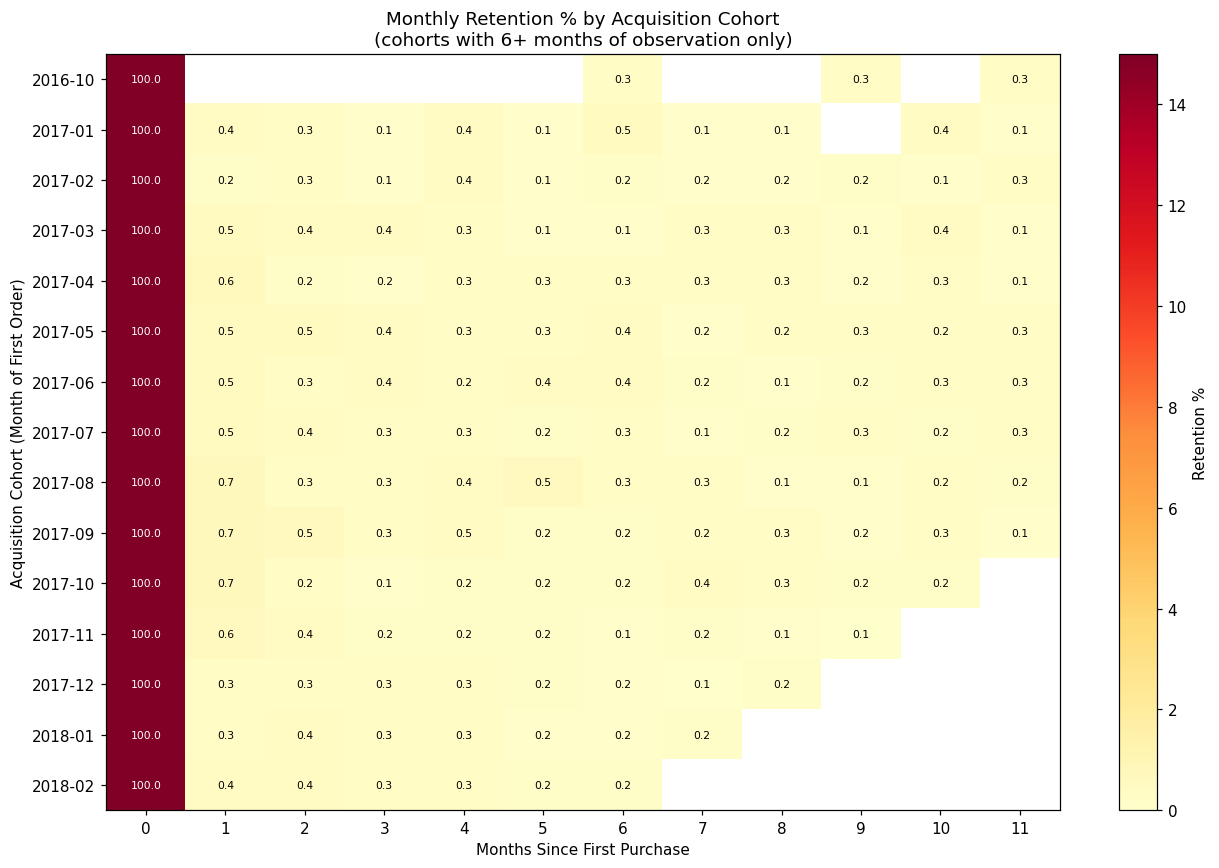

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
# Cap color scale below month 0 (always 100%) so month 1+ variation is visible
data = pivot.values
im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=15)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Acquisition Cohort (Month of First Order)')
ax.set_title('Monthly Retention % by Acquisition Cohort\n(cohorts with 6+ months of observation only)')

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=7, color='white' if val > 7 else 'black')

fig.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.savefig('images/cohort_retention_heatmap.png', dpi=150)
plt.show()

In [7]:
overall_repeat = run_sql('sql/05_overall_repeat_rate.sql')
overall_repeat

,total_customers,repeat_customers,overall_repeat_rate_pct
0,96096,2997.0,3.12


### Right-Censoring Check

The 3.12% figure above is computed across *all* customers regardless of when
they first ordered. But customers whose first order was, say, July or August
2018 have had almost no time to place a second order before the data cuts off
— so they're nearly guaranteed to look like "non-repeaters" for reasons that
have nothing to do with actual behavior. This compares repeat rate for
customers who had at least a full 6-month window to reorder vs. those who
didn't, to check how much this mechanically drags down the headline number.

In [8]:
censoring_df = run_sql('sql/06_repeat_rate_by_observation_window.sql')
censoring_df

,observation_bucket,customers,repeat_customers,repeat_purchase_rate_pct
0,6mo+ observation window,57510,2347.0,4.08
1,under 6mo observation window (censored),38586,650.0,1.68


## 3. Behavioral Cohort: First-Order Review Score vs. Repeat Purchase

In [9]:
review_df = run_sql('sql/03_review_score_cohort.sql')
review_df

,review_group,customers,repeat_customers,repeat_purchase_rate_pct
0,1-3 stars (unsatisfied),21889,674.0,3.08
1,4-5 stars (satisfied),73471,2294.0,3.12


## 4. Geography Segmentation: Top 5 States by Order Volume

In [10]:
geo_df = run_sql('sql/04_geo_segmentation.sql')
geo_df

,customer_state,order_count,customers,repeat_customers,repeat_purchase_rate_pct,avg_order_value
0,SP,41746,40302,1296.0,3.22,143.69
1,RJ,12852,12384,421.0,3.40,166.85
2,MG,11635,11259,338.0,3.00,160.92
3,RS,5466,5277,167.0,3.16,162.99
4,PR,5045,4882,145.0,2.97,160.78


### Repeat Purchase Rate: Review-Score Groups vs. Top States

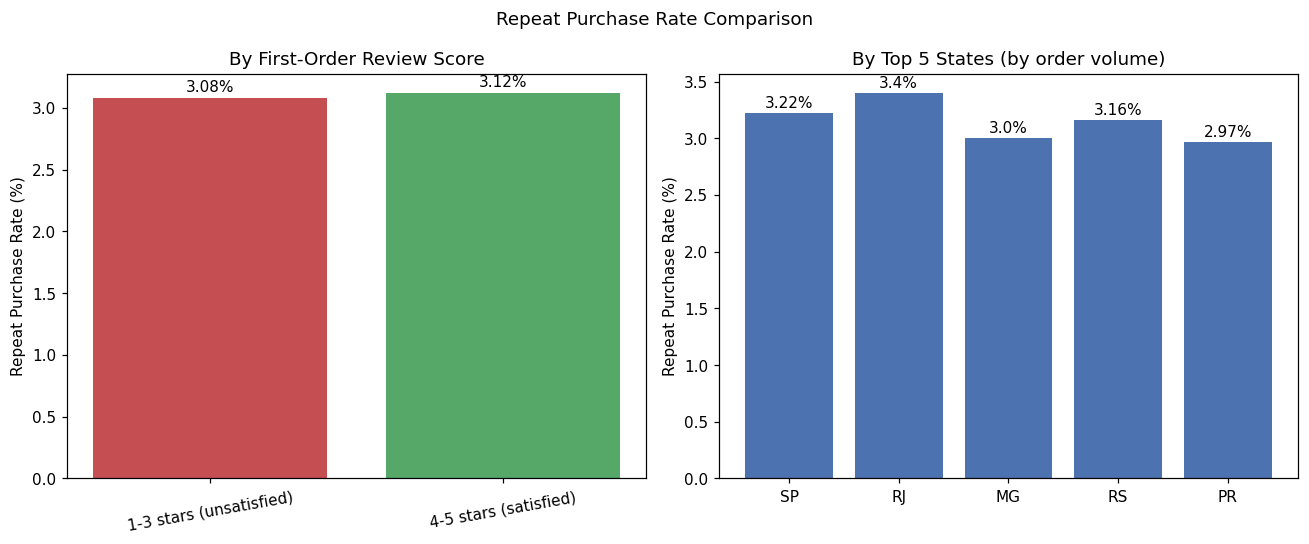

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(review_df['review_group'], review_df['repeat_purchase_rate_pct'],
            color=['#C44E52', '#55A868'])
axes[0].set_ylabel('Repeat Purchase Rate (%)')
axes[0].set_title('By First-Order Review Score')
for i, v in enumerate(review_df['repeat_purchase_rate_pct']):
    axes[0].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)
axes[0].tick_params(axis='x', labelrotation=10)

axes[1].bar(geo_df['customer_state'], geo_df['repeat_purchase_rate_pct'], color='#4C72B0')
axes[1].set_ylabel('Repeat Purchase Rate (%)')
axes[1].set_title('By Top 5 States (by order volume)')
for i, v in enumerate(geo_df['repeat_purchase_rate_pct']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)

fig.suptitle('Repeat Purchase Rate Comparison')
plt.tight_layout()
plt.savefig('images/repeat_rate_comparison.png', dpi=150)
plt.show()

## Summary

See `README.md` for the full write-up with findings and a stakeholder recommendation.